# Intrusion Detection using Machine Learning on ALLFLOWMETER_HIKARI2021

## Objective
The objective of this notebook is to build and evaluate supervised Machine Learning models capable of detecting malicious network traffic using the **ALLFLOWMETER_HIKARI2021** dataset.

The target variable is `Label`, where the expected interpretation is:

- `0` = benign traffic
- `1` = malicious / attack traffic

This work follows the AI for Cybersecurity workflow: dataset understanding, preprocessing, model training, evaluation, and cybersecurity interpretation.


## Research question

**Can supervised Machine Learning models accurately distinguish benign network flows from malicious network flows using flow-based features from the ALLFLOWMETER_HIKARI2021 dataset?**

From a cybersecurity perspective, the most critical operational requirement is not only high global accuracy, but also strong **attack recall**, because false negatives represent attacks that the IDS fails to detect.


## Dataset description

The ALLFLOWMETER_HIKARI2021 dataset contains network-flow features extracted from traffic captures. Each row represents a network flow and includes statistical traffic features such as packet counts, byte counts, duration, inter-arrival timing, and protocol behaviour.

This dataset is relevant for cybersecurity because it supports the development of **Intrusion Detection Systems (IDS)**. In this context, Machine Learning models learn patterns that differentiate benign activity from suspicious or malicious traffic.

The notebook assumes that the dataset file is available in one of the following locations:

- `../../data/raw/ALLFLOWMETER_HIKARI2021.csv`


## 1. Environment setup and imports

This step prepares the Python environment used for the full Machine Learning pipeline.

**Why this matters:** a notebook is only useful if another person can rerun it. Importing all libraries at the beginning makes the dependencies visible and supports reproducibility.

**What is imported:**

- `pandas` and `numpy` for tabular data processing.
- `matplotlib` for charts.
- `pathlib` for robust file-path handling.
- `scikit-learn` modules for train/test split, scaling, model training, metrics and visual evaluation.

The `RANDOM_STATE` variable fixes the pseudo-random operations. This does not make the model universally deterministic in every platform, but it strongly improves reproducibility for splits and model initialization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)


## 2. Load dataset

This step loads the CSV file into a pandas DataFrame.

**Why this matters:** the dataset is the input asset of the IDS experiment. If the file path is hard-coded for only one computer, the notebook becomes fragile. Therefore, the code checks multiple likely paths:

1. `../../data/raw/ALLFLOWMETER_HIKARI2021.csv`
2. `data/raw/ALLFLOWMETER_HIKARI2021.csv`
3. `ALLFLOWMETER_HIKARI2021.csv`

This makes the notebook easier to execute in VS Code, Jupyter, GitHub Codespaces, or a local project folder.

**Expected output:** the first rows of the dataset. This confirms that the file was loaded and that the column names are available for the next steps.

In [3]:
candidate_paths = [
    Path("../../data/raw/ALLFLOWMETER_HIKARI2021.csv"),
    Path("data/raw/ALLFLOWMETER_HIKARI2021.csv"),
    Path("ALLFLOWMETER_HIKARI2021.csv")
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        "Dataset not found. Place ALLFLOWMETER_HIKARI2021.csv in ../../data/raw/, data/raw/, "
        "or the notebook folder."
    )

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)
df.head()


Loading dataset from: ../../data/raw/ALLFLOWMETER_HIKARI2021.csv


,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.

## 3. Initial dataset inspection

This step performs the first data-quality checkpoint.

**What is checked:**

- Dataset size: number of rows and columns.
- Column names: confirms whether the expected features and labels exist.
- Data types: separates numeric, categorical, and object/string fields.
- First rows: gives a quick view of the structure.
- Missing values: identifies incomplete data.
- Duplicates: detects repeated samples that may bias training.

**Why this matters for cybersecurity:** IDS datasets can contain identifiers, IP addresses, categorical labels, timestamps and numeric flow features. Not all columns should be used for model training. This inspection prevents blind modelling and helps avoid leakage or non-generalizable features.

In [4]:
print("Dataset shape (lines, columns):", df.shape)
print("Columns:")
print(df.columns.tolist())

print("Data types:")
display(df.dtypes.value_counts())

print("First rows:")
display(df.head())


Dataset shape (lines, columns): (555278, 88)
Columns:
['Unnamed: 0.1', 'Unnamed: 0', 'uid', 'originh', 'originp', 'responh', 'responp', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_paylo

float64    56
int64      28
str         4
Name: count, dtype: int64

First rows:


,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.

In [5]:
print("Dataset info:")
df.info()

missing_values = df.isna().sum().sort_values(ascending=False)
print("Total missing values:", int(missing_values.sum()))
display(missing_values[missing_values > 0].head(20))

print("Duplicated rows:", int(df.duplicated().sum()))


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 555278 entries, 0 to 555277
Data columns (total 88 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0.1              555278 non-null  int64  
 1   Unnamed: 0                555278 non-null  int64  
 2   uid                       555278 non-null  str    
 3   originh                   555278 non-null  str    
 4   originp                   555278 non-null  int64  
 5   responh                   555278 non-null  str    
 6   responp                   555278 non-null  int64  
 7   flow_duration             555278 non-null  float64
 8   fwd_pkts_tot              555278 non-null  int64  
 9   bwd_pkts_tot              555278 non-null  int64  
 10  fwd_data_pkts_tot         555278 non-null  int64  
 11  bwd_data_pkts_tot         555278 non-null  int64  
 12  fwd_pkts_per_sec          555278 non-null  float64
 13  bwd_pkts_per_sec          555278 non-null

Series([], dtype: int64)

Duplicated rows: 0


## 4. Label and traffic category analysis

This step studies the target variable and the available traffic categories.

**Why this matters:** supervised learning requires a target variable. In this notebook, the target is `Label`, where the model learns to classify each network flow as benign or malicious.

**Cybersecurity angle:** IDS datasets are often imbalanced. For example, benign traffic may dominate the dataset, or some attack types may appear much less frequently than others. If the classes are imbalanced, a model can achieve high accuracy while still missing many attacks.

**What to look for:**

- Is the dataset mostly benign or mostly malicious?
- Are attack categories evenly represented?
- Is the target binary or multi-class?
- Would accuracy alone be misleading?

The bar charts help translate raw counts into an operational view of the detection problem.

In [6]:
#selects column names from df whose names that contains "category", "label", or "traffic" (case insensitive)
label_related_cols = df.columns[df.columns.str.contains("category|label|traffic", case=False, regex=True)]
label_related_cols.tolist() #converts that Index into a plain Python list of column name strings.


['traffic_category', 'Label']

In [7]:
#Ensures the notebook stops with a clear error if the expected "label" column is not present in the dataset.
if "Label" not in df.columns:
    raise KeyError("Expected target column 'Label' was not found in the dataset.")

label_counts = df["Label"].value_counts().sort_index() #Counts the occurrences of each unique value in the "Label"
label_percent = df["Label"].value_counts(normalize=True).sort_index() * 100 #Calculates the percentage of each unique value in the "Label" column.

label_summary = pd.DataFrame({"count": label_counts, "percentage": label_percent.round(2)}) #Creates a DataFrame with the label counts and percentages.
display(label_summary) #Shows the table in the notebook for inspection and reporting


,count,percentage
Label,,
0,517582,93.21
1,37696,6.79


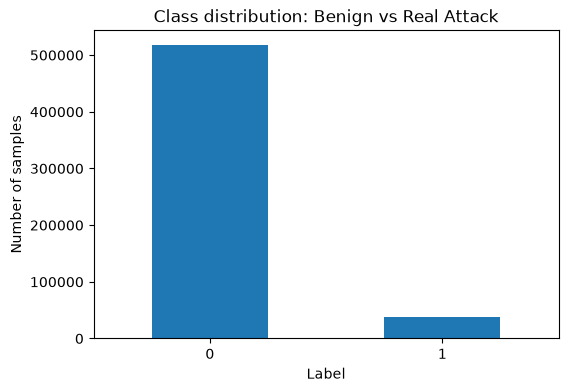

In [8]:
plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Class distribution: Benign vs Real Attack")
plt.xlabel("Label")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.show()


,count,percentage
traffic_category,,
Benign,347431,62.57
Background,170151,30.64
Probing,23388,4.21
Bruteforce,5884,1.06
Bruteforce-XML,5145,0.93
XMRIGCC CryptoMiner,3279,0.59


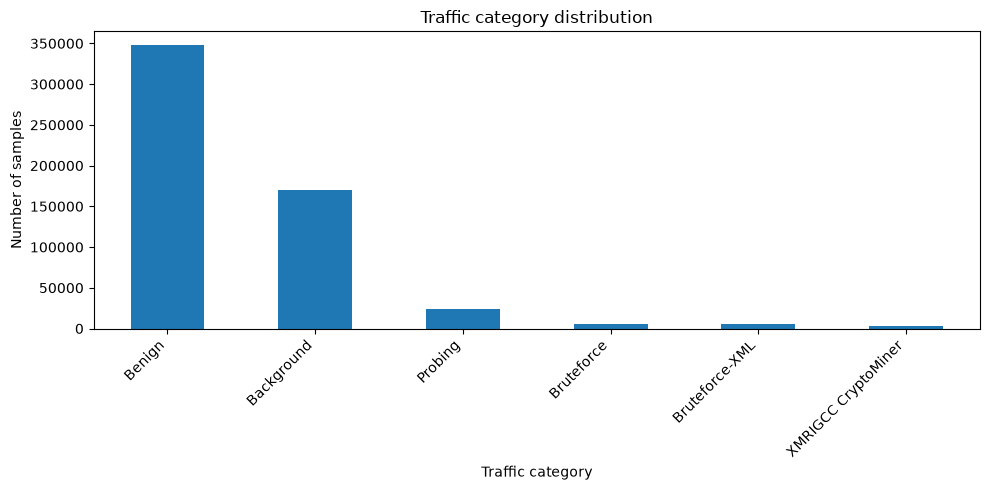

Label,0,1
traffic_category,,
Background,170151,0
Benign,347431,0
Bruteforce,0,5884
Bruteforce-XML,0,5145
Probing,0,23388
XMRIGCC CryptoMiner,0,3279


In [9]:
#traffic_category analysis
if "traffic_category" in df.columns: 
    traffic_summary = pd.DataFrame({
        "count": df["traffic_category"].value_counts(),
        "percentage": (df["traffic_category"].value_counts(normalize=True) * 100).round(2)
    })
    display(traffic_summary) 

    plt.figure(figsize=(10, 5))
    df["traffic_category"].value_counts().plot(kind="bar")
    plt.title("Traffic category distribution")
    plt.xlabel("Traffic category")
    plt.ylabel("Number of samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(pd.crosstab(df["traffic_category"], df["Label"]))
else:
    print("Column 'traffic_category' not found. Skipping traffic category analysis.")


## 5. Quick dataset summary

This step creates a compact summary of the dataset.

**Purpose:** this information can be reused later in the written report or presentation. It also acts as a quality gate before moving into preprocessing.

**Why it matters:** when reporting a Machine Learning experiment, the reader must know the dataset size, number of features, missing values, duplicates and number of target classes. Without this, the methodology is incomplete and hard to reproduce.

In [25]:
#summary of the dataset.
summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "duplicates": int(df.duplicated().sum()),
    "missing_values_total": int(df.isna().sum().sum()),
    "target_column": "Label",
    "number_of_classes label": int(df["Label"].nunique())
}
#display(df.tail(5))
display(summary)


{'rows': 555278,
 'columns': 88,
 'duplicates': 0,
 'missing_values_total': 0,
 'target_column': 'Label',
 'number_of_classes label': 2}

## 6. Feature preparation

This step defines the model input matrix `X` and the target vector `y`.

**What happens here:**

- `Label` is separated as the target variable.
- Identifier columns are removed.
- Network host fields such as origin/responder identifiers are removed.
- Categorical descriptors such as `traffic_category` are excluded from the numeric baseline model.
- Only numeric features are selected for training.

**Why this matters:** identifiers such as unique IDs, IP-like fields, or dataset-specific indexes can create misleading performance. The model may memorize dataset artifacts instead of learning generalizable traffic behaviour.

**Trade-off:** removing categorical fields simplifies the baseline and reduces leakage risk, but it may also discard useful information. A future improvement could encode selected categorical features using one-hot encoding, but only after verifying that they are legitimate predictors and not leakage fields.

In [ ]:
target_col = "Label"

drop_cols = [
    "Unnamed: 0.1",
    "Unnamed: 0",
    "uid",
    "originh",
    "responh",
    "traffic_category",
    "Label"
]

# Removes the specified columns from the DataFrame df to create a new DataFrame X_raw, 
# which will be used as the feature matrix for machine learning. 
# The errors="ignore" parameter ensures that if any of the specified columns are not found in df, 
# no error will be raised, and those columns will simply be ignored.
X_raw = df.drop(columns=drop_cols, errors="ignore")

#Builds the target variable y by selecting the "Label" column from df and converting its data type to integer. 
# This is necessary for machine learning algorithms that require numerical input.
y = df[target_col].astype(int)

# Selects only the numeric columns from X_raw to create a new DataFrame X, 
# which will be used as the feature matrix for machine learning.
X = X_raw.select_dtypes(include=["number"]).copy()

print("Original feature matrix shape:", X_raw.shape)
print("Numeric feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of selected numeric features:", X.shape[1])
display(X.head())


Original feature matrix shape: (555278, 81)
Numeric feature matrix shape: (555278, 81)
Target shape: (555278,)
Number of selected numeric features: 81


,originp,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
0,13316,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0
1,13318,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0
2,13320,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0
3,13322,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.931318,9.759205e+06,9.759205e+06,9.759205e+06,9.759205e+06,0.0,29200,65160,0
4,13324,443,7.780611,14,14,6,5,1.799345,1.799345,3.598689,1.000000,432,20,40,480,32,44,2,2,2,6,5,25,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,358.928571,792.173394,0.0,2896.0,6853.0,244.750000,583.468215,16.927719,7.545305e+06,

## 7. Cleaning missing and infinite values

This step prepares numeric features so that scikit-learn models can process them.

**Problem:** ML algorithms usually cannot train with `NaN`, `inf`, or `-inf` values. These values can appear in network-flow datasets due to divisions by zero, missing measurements, extraction errors, or abnormal traffic behaviour.

**Solution used here:**

1. Convert infinite values into missing values.
2. Replace missing values with the median value of each feature.

**Why median:** the median is more robust than the mean when features contain extreme outliers, which is common in traffic-flow data.

**Important limitation:** imputation changes the data. In a final paper, this decision should be documented because preprocessing choices directly affect model performance.

In [ ]:
#replaces any infinite values in the DataFrame X with NaN (Not a Number) to 
# handle potential issues during data preprocessing and model training. 
# This is important because infinite values can cause errors or unexpected behavior in machine learning algorithms.
X = X.replace([np.inf, -np.inf], np.nan) 

#Reports the number of missing values in the feature matrix before and after 
# filling them with the median of each column.
missing_before = int(X.isna().sum().sum())
X = X.fillna(X.median(numeric_only=True))
missing_after = int(X.isna().sum().sum())

print("Missing values before cleaning:", missing_before)
print("Missing values after cleaning:", missing_after)


Missing values before cleaning: 0
Missing values after cleaning: 0


## 8. Exploratory feature analysis

This step checks which numeric features have the strongest linear association with the target label.

**What correlation tells us:** a high absolute correlation means that a feature changes consistently with the label. This can indicate that the feature helps separate benign and malicious flows.

**What correlation does not tell us:** correlation is not causation and does not capture complex non-linear relationships. A feature with low correlation may still be useful for Random Forest or other non-linear models.

**Why this matters for IDS:** feature analysis supports explainability. Instead of treating the model as a black box, we start identifying which traffic characteristics appear relevant for attack detection.

In [13]:
numeric_df = pd.concat([X, y.rename("Label")], axis=1)
correlations = numeric_df.corr(numeric_only=True)["Label"].abs().sort_values(ascending=False)

display(correlations.head(16))


Label                    1.000000
bwd_init_window_size     0.321053
bwd_header_size_max      0.291120
fwd_pkts_payload.std     0.283017
bwd_header_size_min      0.281358
fwd_pkts_payload.max     0.265688
bwd_bulk_rate            0.249869
flow_RST_flag_count      0.244015
flow_SYN_flag_count      0.239297
flow_FIN_flag_count      0.231533
fwd_header_size_max      0.220685
fwd_init_window_size     0.214189
fwd_pkts_payload.avg     0.208203
bwd_pkts_payload.std     0.200748
flow_pkts_payload.std    0.194539
flow_pkts_payload.avg    0.182477
Name: Label, dtype: float64

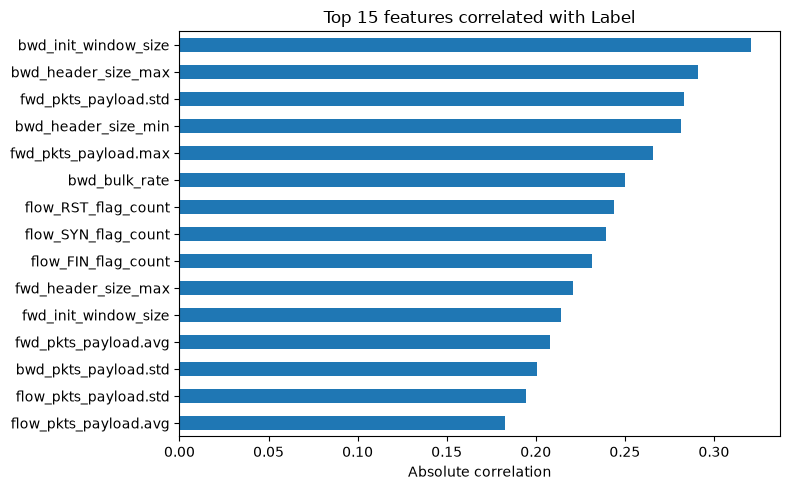

In [14]:
top_corr = correlations.drop("Label", errors="ignore").head(15).sort_values()

plt.figure(figsize=(8, 5))
top_corr.plot(kind="barh")
plt.title("Top 15 features correlated with Label")
plt.xlabel("Absolute correlation")
plt.tight_layout()
plt.show()


## 9. Train/test split

This step separates the dataset into training and testing subsets.

**Training set:** used by the model to learn patterns.

**Test set:** kept aside and used only after training to estimate performance on unseen data.

**Why stratification is used:** `stratify=y` preserves the class distribution in both train and test subsets. This is important for IDS because class imbalance can distort the evaluation if one split receives proportionally more attacks than the other.

**Why this matters:** evaluating on the same data used for training would inflate performance and create a false sense of security. The test set acts as an independent validation gate.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:")
display(y_train.value_counts(normalize=True).sort_index().rename("train_percentage") * 100)
print("Testing labels:")
display(y_test.value_counts(normalize=True).sort_index().rename("test_percentage") * 100)


Training features: (444222, 81)
Testing features: (111056, 81)
Training labels:


Label
0    93.211277
1     6.788723
Name: train_percentage, dtype: float64

Testing labels:


Label
0    93.211533
1     6.788467
Name: test_percentage, dtype: float64

## 10. Scaling for Logistic Regression

This step standardizes the feature values for Logistic Regression.

**Why scaling is needed:** Logistic Regression is sensitive to feature magnitude. A feature measured in large numerical ranges can dominate another feature measured in smaller ranges, even if it is not more important.

**Data leakage control:** the scaler is fitted only on the training set using `fit_transform`. The test set is transformed using the same scaler with `transform`. This prevents information from the test set from influencing training.

**Why Random Forest is not scaled:** tree-based models split features by thresholds and are generally not sensitive to feature scaling. Therefore, Random Forest is trained with the original numeric values.

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 11. Model 1 — Logistic Regression

Logistic Regression is used as the first baseline model.

**Why this model is useful:**

- It is simple and fast.
- It is interpretable compared with complex models.
- It provides class probabilities through `predict_proba`.
- It is a strong baseline for binary classification.

**Cybersecurity interpretation:** Logistic Regression can show whether a linear decision boundary is enough to separate benign and malicious flows. If it performs well, the dataset may contain strong linear patterns. If it performs poorly, more complex models may be required.

**Class imbalance control:** `class_weight="balanced"` increases the penalty for mistakes in the minority class. This is important when attacks are underrepresented or when recall for attacks is operationally critical.

In [17]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_score_log = log_model.predict_proba(X_test_scaled)[:, 1]


/Users/sergiofaria/Documents/AI4Cyber_HIKARI_IDS/notebooks/IAAC_37269_37276/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## 12. Model 2 — Random Forest

Random Forest is used as a stronger non-linear baseline.

**Why this model is useful:**

- It combines multiple decision trees.
- It can learn non-linear relationships between network-flow features and labels.
- It is robust for tabular datasets.
- It provides feature-importance values.

**Cybersecurity interpretation:** network attacks may not be separable by a simple linear rule. Random Forest can capture interactions such as packet count, duration and byte-rate patterns that jointly indicate malicious behaviour.

**Important risk:** Random Forest can overfit if not tuned correctly. This is why evaluation on the test set and future hyperparameter tuning are required.

In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_score_rf = rf_model.predict_proba(X_test)[:, 1]


## 13. Model 3 — Decision Tree

Decision Tree is added as an interpretable supervised-learning model.

**Why this model is useful:**

- It creates decision rules that are easy to explain.
- It is suitable for tabular cybersecurity datasets.
- It helps compare a simple interpretable tree against Logistic Regression and Random Forest.
- It can expose which traffic features are used to separate benign and malicious flows.

**Cybersecurity meaning:** a Decision Tree can be useful when analysts need understandable IDS logic, not only a black-box prediction. However, unrestricted trees can overfit the training data, so this notebook limits the depth and leaf size.

In [19]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_score_dt = dt_model.predict_proba(X_test)[:, 1]

## 14. Evaluation methodology

This step defines how model performance is measured.

The following metrics are used:

- **Accuracy:** global percentage of correct predictions.
- **Precision:** among predicted attacks, how many were really attacks.
- **Recall:** among real attacks, how many were detected.
- **F1-score:** harmonic balance between precision and recall.
- **ROC-AUC:** ranking quality across decision thresholds.
- **PR-AUC:** especially useful when the positive class is imbalanced.

**IDS-specific priority:** recall for the attack class is operationally critical. A false negative means an attack was missed. However, precision also matters because too many false positives create alert fatigue and reduce SOC efficiency.

**Bottom line:** the best model is not automatically the one with the highest accuracy. The best model is the one with the best risk-balanced detection profile.

### Evaluation function explanation

The function below centralizes the evaluation logic so that every model is assessed using the same criteria.

**Why this is good practice:** without a common evaluation function, it is easy to compare models inconsistently. A standardized function reduces reporting errors and makes the notebook easier to extend with more algorithms later.

The function returns a dictionary with the main metrics and also prints the classification report and confusion matrix.

In [20]:
def evaluate_model(model_name, y_true, y_pred, y_score):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score)
    }

    print(f"
=== {model_name} ===")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return results


SyntaxError: unterminated f-string literal (detected at line 12) (3026728029.py, line 12)

### Model comparison table

The table below consolidates the performance of all models into one view.

**How to use this table:**

- Start with recall to understand detection capability.
- Check precision to estimate alert quality.
- Use F1-score to compare the precision/recall balance.
- Use ROC-AUC and PR-AUC to evaluate probability ranking quality.

For the final report, select the model based on IDS risk, not only on the highest accuracy.

In [ ]:
results_log = evaluate_model("Logistic Regression", y_test, y_pred_log, y_score_log)
results_dt = evaluate_model("Decision Tree", y_test, y_pred_dt, y_score_dt)
results_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_score_rf)

results_df = pd.DataFrame([results_log, results_dt, results_rf])
results_df

## 15. Confusion matrices

The confusion matrix translates model results into operational IDS outcomes.

- **True Positive (TP):** attack correctly detected.
- **False Positive (FP):** benign traffic incorrectly flagged as attack.
- **False Negative (FN):** attack missed by the model.
- **True Negative (TN):** benign traffic correctly classified.

**How to read it:**

- High TP means strong attack detection.
- High FN means dangerous blind spots.
- High FP means analyst workload and alert fatigue.
- High TN means benign traffic is correctly ignored.

False negatives are usually the highest-risk error in intrusion detection because they represent real malicious activity passing undetected.

In [ ]:
for model_name, y_pred in [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf)
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Attack"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

## 16. ROC and Precision-Recall curves

This step compares models beyond a fixed classification threshold.

**ROC curve:** shows the trade-off between true-positive rate and false-positive rate. It is useful for general ranking performance.

**Precision-Recall curve:** shows the trade-off between precision and recall. It is especially relevant in cybersecurity datasets where the attack class may be less frequent.

**Why this matters:** the default threshold is usually 0.5, but IDS deployments may require a different threshold. For example, a security team may choose a lower threshold to increase attack recall, accepting more false positives.

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_score_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_score_dt, name="Decision Tree")
RocCurveDisplay.from_predictions(y_test, y_score_rf, name="Random Forest")
plt.title("ROC Curve Comparison")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_score_log, name="Logistic Regression")
PrecisionRecallDisplay.from_predictions(y_test, y_score_dt, name="Decision Tree")
PrecisionRecallDisplay.from_predictions(y_test, y_score_rf, name="Random Forest")
plt.title("Precision-Recall Curve Comparison")
plt.show()

## 17. Decision Tree feature importance

This step identifies which features contributed most to the Decision Tree decisions.

**Why this matters:** Decision Trees are easier to interpret than many ensemble models. Feature importance helps explain which network-flow attributes are most influential in separating benign and malicious traffic.

**Important caution:** feature importance does not prove causality. It only shows which variables the trained model used most often or most effectively for splitting the data.

In [ ]:
dt_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

dt_feature_importance.head(15)

In [ ]:
dt_top_features = dt_feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(dt_top_features["Feature"], dt_top_features["Importance"])
plt.title("Top 15 Decision Tree feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 18. Random Forest feature importance

This step identifies which features contributed most to Random Forest decisions.

**Why this matters:** cybersecurity models should not be evaluated only as black boxes. Feature importance gives a first layer of explainability and helps answer questions such as:

- Which network-flow properties are most relevant?
- Are decisions based on plausible traffic behaviour?
- Are there suspicious leakage features?
- Can analysts understand why the model detects attacks?

**Caution:** built-in Random Forest importance can be biased toward features with many possible split points. For stronger scientific work, permutation importance or SHAP can be added later.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance.head(15))


In [ ]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 19. Cybersecurity interpretation of results

This section converts statistical results into cybersecurity meaning.

The final model should not be selected only by accuracy. In an IDS, the business and security impact of each error type is different:

- **False negatives** mean malicious flows are not detected. This can allow compromise, lateral movement, data leakage, or persistence.
- **False positives** mean benign flows are flagged as malicious. This increases alert fatigue and can overload SOC analysts.

**Decision logic:**

- If recall is low, the model is risky because attacks are missed.
- If precision is low, the model may be noisy and expensive to operate.
- If F1-score is balanced, the model may be operationally more sustainable.
- If PR-AUC is strong, the model ranks attack traffic well even under imbalance.

A model with high accuracy but weak attack recall may look good academically but fail operationally.

## 20. Results discussion

This section should be completed after running the notebook and observing the actual metrics.

Recommended interpretation logic:

- **Logistic Regression** is the linear baseline. It is useful to understand whether the problem can be solved with a simple decision boundary.
- **Decision Tree** is the interpretable non-linear model. It can reveal simple rules but may overfit if the tree is too deep.
- **Random Forest** is the ensemble model. It normally improves robustness by combining many decision trees, but its operational value must still be judged by recall, precision and false negatives.

For an IDS, the best model is not automatically the one with the highest accuracy. The key business/security question is: **which model detects the highest number of attacks while keeping false alarms operationally manageable?**

## 21. Limitations

This section defines the boundaries of the work. A strong academic project is transparent about what was not solved.

Current limitations:

1. The evaluation uses a single train/test split. Cross-validation would provide a more robust estimate.
2. Only two baseline models are tested. Additional models such as XGBoost, LightGBM, SVM, or MLP could improve results.
3. Hyperparameter tuning is not yet performed.
4. The model is evaluated offline, not in a real-time IDS deployment.
5. The dataset may not fully represent current production network behaviour.
6. Feature removal is conservative; some removed categorical features may be useful if encoded correctly.
7. No adversarial robustness testing is performed.
8. No explainability technique beyond Random Forest feature importance is included.

**Why this matters:** limitations protect the credibility of the work. They show that the author understands the difference between a controlled experiment and a production-grade IDS.

## 22. Future work

This section defines the improvement roadmap.

Recommended next steps:

- Add hyperparameter tuning using `GridSearchCV`, `RandomizedSearchCV`, or Optuna.
- Test additional algorithms such as XGBoost, LightGBM, SVM, and neural networks.
- Perform cross-validation.
- Optimize the classification threshold to reduce false negatives while controlling false positives.
- Add SHAP or permutation importance for stronger explainability.
- Validate the model on unseen traffic or a different IDS dataset.
- Discuss deployment options such as on-premises IDS, edge sensor, or SOC analytics pipeline.
- Add model-saving/export using `joblib`.
- Add inference example for one new network flow.

**Strategic direction:** the next maturity step is moving from a classroom ML experiment to a reproducible IDS prototype.

## Submission checklist

Before submitting the work, verify the following items:

- The notebook runs from top to bottom without errors.
- The dataset path is documented.
- The target variable is clearly explained.
- The class distribution is discussed.
- At least two models are compared.
- Metrics are interpreted from an IDS perspective.
- False positives and false negatives are explicitly discussed.
- The conclusion states which model is preferred and why.
- References are included.
- The notebook contains markdown explanations, not only code.

## 23. Conclusion

This notebook demonstrates a supervised Machine Learning pipeline for intrusion detection using the ALLFLOWMETER_HIKARI2021 dataset.

The work includes:

- Dataset loading and inspection.
- Exploratory Data Analysis.
- Data cleaning and feature preparation.
- Train/test split with stratification.
- Logistic Regression baseline.
- Random Forest baseline.
- Evaluation using accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC and confusion matrices.
- Cybersecurity-oriented interpretation.

**Main takeaway:** model selection for cybersecurity must consider operational risk. Accuracy alone is insufficient. A useful IDS model must reduce false negatives without creating an unsustainable number of false positives.

**Final positioning:** this notebook is a solid baseline implementation. With hyperparameter tuning, threshold optimization, cross-validation, stronger explainability and references, it can evolve into a stronger academic submission.

## References

- HIKARI2021 / ALLFLOWMETER_HIKARI2021 dataset documentation.
- Scikit-learn documentation: supervised learning, Logistic Regression, Random Forest and model evaluation metrics.
- Rui Fernandes, *AI for Cybersecurity* course materials.
- Rui Fernandes, *Scientific Writing - Introduction* course materials.

**Note for final submission:** replace these generic references with full formal citations if the report requires IEEE/APA format. At minimum, cite the dataset source, scikit-learn, and any algorithm or methodology references used in the discussion.